<div style="text-align:center; font-weight:bold; font-size:34px; margin-top:40px;">
    Module 0 — Input Data Preparation
</div>

<p style="text-align:center; font-size:20px; color:#444; margin-top:5px;">
    PyAEZ Version 3.0 &nbsp; | &nbsp; 2026
</p>

<hr style="margin-top:25px; margin-bottom:25px;">

<p style="text-align:center; font-size:18px;">
    This foundational module guides users through the preparation and organization
    of all input datasets required for subsequent workflow components.
</p>

<p style="text-align:center; font-size:16px; color:#555;">
    Prepared by <strong>Dario Spiller</strong><br>
    Geospatial Unit — Land and Water Division (NSL)<br>
    Food and Agriculture Organization of the United Nations (FAO HQ)
</p>

<hr style="margin-top:25px; margin-bottom:25px;">


In [1]:
# =============================================================================
# IMPORT SUPPORTING LIBRARIES
# =============================================================================
# External packages are installed through environment_pyaez.yml.
# Import statements are still required here to make those packages available
# to this running Python/Jupyter session.
# =============================================================================

from pathlib import Path

import numpy as np
import cavapy
import yaml

# Preserve the directory from which this notebook was opened.
# This is used only by the temporary crop-validation mode below so that the
# crop utility and metadata workbook can be tested locally even if
# set_working_folder() changes the current working directory.
M0_START_DIR = Path.cwd().resolve()


In [2]:
# =============================================================================
# SET PyAEZ PROJECT WORKING FOLDER
# =============================================================================
from pyaez import pre_proc_utilities
pre_proc_utilities.set_working_folder()


Notebook directory : D:\Documenti_Lavoro\FAO\Contratto FAO 2025 Sept-Dec\Python-AEZ-FAO\PyAEZ3.0\module0
Project root set to: D:\Documenti_Lavoro\FAO\Contratto FAO 2025 Sept-Dec\Python-AEZ-FAO\PyAEZ3.0


# Input data from the user: Area of Interest, crop, water supply, and scenarios

In [3]:
# =============================================================================
# AREA OF INTEREST
# =============================================================================

AOI, country_name, buffer = pre_proc_utilities.choose_country()

#country_name = 'togo'
#country_name = country_name.lower()
#AOI = pre_proc_utilities.get_UN_country(country_name, thr=3, return_gdf=False)


The country "Togo" was selected from the UN database.


In [ ]:
# =============================================================================
# LOAD MODULE 0 CROP-SELECTION UTILITIES
# =============================================================================
# The final GitHub structure is already defined below.
#
# TEMPORARY LOCAL VALIDATION
# --------------------------
# Keep CROP_VALIDATION_MODE = True while checking the crop-selection workflow
# before uploading the final M0 notebook to GitHub.
#
# In validation mode, the following two files are expected in the same local
# Jupyter folder from which this notebook was opened:
#
#     m0_crop_selection_utilities.ipynb
#     PyAEZ_Parameter_Metadata.xlsx
#
# FINAL GITHUB
# ------------
# Before final release, set CROP_VALIDATION_MODE = False.
# The same code then reads the files from the final PyAEZ3.0 structure:
#
#     utilities/module0/m0_crop_selection_utilities.ipynb
#     data_input/metadata/PyAEZ_Parameter_Metadata.xlsx
# =============================================================================

CROP_VALIDATION_MODE = True

if CROP_VALIDATION_MODE:
    CROP_UTILITY_PATH = M0_START_DIR / "m0_crop_selection_utilities.ipynb"
    CROP_METADATA_PATH = M0_START_DIR / "PyAEZ_Parameter_Metadata.xlsx"
else:
    CROP_UTILITY_PATH = Path(
        "./utilities/module0/m0_crop_selection_utilities.ipynb"
    )
    CROP_METADATA_PATH = Path(
        "./data_input/metadata/PyAEZ_Parameter_Metadata.xlsx"
    )

if not CROP_UTILITY_PATH.exists():
    raise FileNotFoundError(
        "Module 0 crop-selection utility was not found:\n"
        f"{CROP_UTILITY_PATH.resolve()}"
    )

if not CROP_METADATA_PATH.exists():
    raise FileNotFoundError(
        "PyAEZ Parameter Metadata workbook was not found:\n"
        f"{CROP_METADATA_PATH.resolve()}"
    )

# Load the notebook utility functions into the current M0 session.
get_ipython().run_line_magic(
    "run",
    f'"{CROP_UTILITY_PATH}"',
)

if CROP_VALIDATION_MODE:
    print("Crop-selection validation mode: ON")
    print("-" * 65)
    print(f"Utility  : {CROP_UTILITY_PATH}")
    print(f"Metadata : {CROP_METADATA_PATH}")
    print("Sheet    : CODES_CROP")
    print("-" * 65)


In [ ]:
# =============================================================================
# CROP SELECTION
# =============================================================================
# Enter the crop you would like to evaluate.
#
# USER ACTION:
# Change only CROP_SEARCH below.
#
# Type a familiar crop name, for example:
#     "maize"
#     "rice"
#     "wheat"
#     "coffee"
#
# PyAEZ searches the official crop catalogue and shows the closest supported
# crop options. Review the crop name and crop group, select the option that
# best represents the target crop, and click "Confirm crop".
#
# If the target crop does not appear among the suggested options, refer to the
# complete crop catalogue in the PyAEZ Parameter Metadata workbook.
#
# The PyAEZ crop code is assigned automatically. The general user does not
# need to enter or know the internal code.
# =============================================================================

CROP_SEARCH = "maize"


crop_selection = select_crop(
    metadata_path=CROP_METADATA_PATH,
    sheet_name="CODES_CROP",
    default_search=CROP_SEARCH,
    max_options=10,
)

In [ ]:
# =============================================================================
# CONFIRMED CROP SETTINGS
# =============================================================================
# Run this cell only AFTER selecting a crop and clicking "Confirm crop" above.
#
# CROP_CODE, CROP_NAME and CROP_GROUP define the selected PyAEZ v3 crop.
# m4_CROP_NAME is read only after confirmation and provides the corresponding
# legacy Module 4 crop name where a mapping exists.
# =============================================================================

CROP_CODE, CROP_NAME, CROP_GROUP, m4_CROP_NAME = get_confirmed_crop(
    crop_selection
)

# Detailed technical output is shown only during local validation.
if CROP_VALIDATION_MODE:
    print()
    print("PyAEZ crop-selection validation")
    print("=" * 65)
    print(f"User search        : {CROP_SEARCH}")
    print(f"CROP_CODE          : {CROP_CODE}")
    print(f"CROP_NAME          : {CROP_NAME}")
    print(f"CROP_GROUP         : {CROP_GROUP}")
    print(
        f"m4_CROP_NAME       : "
        f"{m4_CROP_NAME if m4_CROP_NAME else 'No Module 4 equivalent'}"
    )

    if m4_CROP_NAME and ";" in m4_CROP_NAME:
        print(
            "M4 mapping note    : Multiple legacy Module 4 crop names "
            "are associated with this PyAEZ crop."
        )

    print("=" * 65)


In [ ]:
# =============================================================================
# SHARED PROJECT SETTINGS
# =============================================================================
# These settings are defined once in Module 0 and are intended to be reused
# by the other PyAEZ modules.
#
# The crop is NOT entered again here. CROP_CODE, CROP_NAME, CROP_GROUP and
# m4_CROP_NAME come from the confirmed crop-selection step above.
#
# USER ACTION:
# Edit only FARMING, WATER and INPUT below.
#
# The management SCENARIO code is generated automatically from WATER and INPUT.
# The user should NOT enter the scenario code manually.
# =============================================================================


# =============================================================================
# USER INPUTS
# =============================================================================

# 1. Farming system
#    "conv" = Conventional farming
#    "org"  = Organic farming
FARMING = "conv"

# 2. Water supply system
#    "RF" = Rainfed
#    "IR" = Irrigated
WATER = "RF"

# 3. Input / management level
#    Conventional farming: "low", "int", "high"
#    Organic farming:      "mod", "adv"
INPUT = "high"


# =============================================================================
# VALIDATION AND AUTOMATIC SETTINGS
# =============================================================================
# General users do not need to edit anything below this line.
# =============================================================================

FARMING = FARMING.strip().lower()
WATER = WATER.strip().upper()
INPUT = INPUT.strip().lower()

if not CROP_CODE or not CROP_NAME:
    raise ValueError(
        "No valid crop has been confirmed. "
        "Please complete the crop-selection step before continuing."
    )

VALID_FARMING = {"conv", "org"}
VALID_WATER = {"RF", "IR"}
VALID_INPUT = {
    "conv": {"low", "int", "high"},
    "org": {"mod", "adv"},
}

if FARMING not in VALID_FARMING:
    raise ValueError(
        f"Invalid FARMING = {FARMING!r}. "
        f"Please select one of: {sorted(VALID_FARMING)}"
    )

if WATER not in VALID_WATER:
    raise ValueError(
        f"Invalid WATER = {WATER!r}. "
        f"Please select one of: {sorted(VALID_WATER)}"
    )

if INPUT not in VALID_INPUT[FARMING]:
    raise ValueError(
        f"INPUT = {INPUT!r} is not valid for FARMING = {FARMING!r}.\n"
        f"Allowed input levels are: {sorted(VALID_INPUT[FARMING])}"
    )

# =============================================================================
# BUILD MANAGEMENT SCENARIO CODE
# =============================================================================
# Current PyAEZ management codes:
#
# HILM = Irrigation + high input level
# LILM = Irrigation + low input level
# LRLM = Rainfed + low input level
# HRLM = Rainfed + high input level
#
# The current code table does not yet define codes for conventional
# intermediate input ("int") or organic moderate/advanced input ("mod"/"adv").
# Undefined combinations therefore return SCENARIO = None rather than an
# invented code.
# =============================================================================

MANAGEMENT_CODE_MAP = {
    ("IR", "high"): "HILM",
    ("IR", "low"): "LILM",
    ("RF", "low"): "LRLM",
    ("RF", "high"): "HRLM",
}

SCENARIO = MANAGEMENT_CODE_MAP.get((WATER, INPUT))

MANAGEMENT_DESCRIPTION = {
    "HILM": "Irrigation and high input level of management",
    "LILM": "Irrigation and low input level of management",
    "LRLM": "Rainfed and low input level of management",
    "HRLM": "Rainfed and high input level of management",
}

SCENARIO_DESCRIPTION = (
    MANAGEMENT_DESCRIPTION.get(SCENARIO)
    if SCENARIO is not None
    else "Management code not yet defined"
)

print("\nPyAEZ shared project settings")
print("=" * 65)
print(f"Crop                 : {CROP_NAME}")
print(f"Crop group           : {CROP_GROUP}")
print(f"Farming system       : {FARMING}")
print(f"Water supply         : {WATER}")
print(f"Input level          : {INPUT}")

if SCENARIO is not None:
    print(f"Management code      : {SCENARIO}")
    print(f"Management definition: {SCENARIO_DESCRIPTION}")
else:
    print("Management code      : Not currently defined")
    print(
        "Note                 : The current management-code table does not "
        f"contain a code for WATER={WATER} and INPUT={INPUT}."
    )

print("=" * 65)


## Save the selected AOI and shared PyAEZ project settings


In [ ]:
# =============================================================================
# SAVE SHARED PyAEZ PROJECT CONFIGURATION
# =============================================================================
# Save the exact AOI selected in Module 0 together with the confirmed crop and
# management settings for reuse by subsequent PyAEZ modules.
#
# No AOI key, lowercase label, or derived filename label is created.
# =============================================================================

SHARED_CONFIG_PATH = Path("./data_input/project_config.yml")
AOI_EXPORT_DIR = Path("./data_input/AOI")
AOI_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Use the exact country_name returned by choose_country().
AOI_VECTOR_PATH = AOI_EXPORT_DIR / f"{country_name}_aoi.gpkg"

# Replace an earlier export of the same selected AOI.
if AOI_VECTOR_PATH.exists():
    AOI_VECTOR_PATH.unlink()

AOI.to_file(
    AOI_VECTOR_PATH,
    layer="aoi",
    driver="GPKG",
)

buffer_value = float(buffer) if buffer is not None else 0.0
aoi_crs = AOI.crs.to_string() if AOI.crs is not None else None

PROJECT_CONFIG = {
    "aoi": {
        "name": country_name,
        "vector_path": AOI_VECTOR_PATH.as_posix(),
        "layer": "aoi",
        "buffer": buffer_value,
        "crs": aoi_crs,
    },
    "crop": {
        "code": CROP_CODE,
        "name": CROP_NAME,
        "group": CROP_GROUP,
    },
    "management": {
        "farming": FARMING,
        "water": WATER,
        "input": INPUT,
        "scenario": SCENARIO,
        "scenario_description": SCENARIO_DESCRIPTION,
    },
    "module4": {
        "crop_name": m4_CROP_NAME if m4_CROP_NAME else None,
        "water": WATER,
        "scenario": SCENARIO,
    },
}

SHARED_CONFIG_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

with SHARED_CONFIG_PATH.open(
    "w",
    encoding="utf-8",
) as config_file:
    yaml.safe_dump(
        PROJECT_CONFIG,
        config_file,
        sort_keys=False,
        allow_unicode=True,
    )

print("\nShared PyAEZ configuration saved")
print("=" * 65)
print(f"AOI                 : {country_name}")
print(f"AOI geometry        : {AOI_VECTOR_PATH}")
print(f"Configuration       : {SHARED_CONFIG_PATH}")
print(f"Crop                : {CROP_NAME}")
print(f"Crop code           : {CROP_CODE}")
print(f"Crop group          : {CROP_GROUP}")
print(f"Water supply        : {WATER}")
print(f"Farming system      : {FARMING}")
print(f"Input level         : {INPUT}")
print(
    f"Management scenario : "
    f"{SCENARIO if SCENARIO else 'Not defined'}"
)
print(
    f"Module 4 crop       : "
    f"{m4_CROP_NAME if m4_CROP_NAME else 'No equivalent'}"
)
print("=" * 65)


In [ ]:
AOI

In [4]:
scenario = pre_proc_utilities.choose_scenario()#year = 1980
year = scenario['year']
management = scenario['management']

#rcp = "rcp26"
#gcm = "MOHC" # [MOHC, NCC, MPI]
#rcm = 'REMO' # [ICTP, REMO] 
#historical = True
#management = 'HI' # high input ('HI') or low input ('LI')


The chosen values for the current simulation are: {'year': 1985, 'rcp': 'rcp85', 'gcm': 'NCC', 'rcm': 'Reg', 'historical': True, 'management': 'HI'}


# Loading climate data 

In [5]:
years_up_to = np.max([year+1, 2007])   
country_name_capitalized = country_name.capitalize()
    
CAVA_climate_data = cavapy.get_climate_data(country=country_name_capitalized, 
                                             cordex_domain="AFR-22", #AFR-22
                                             buffer=buffer,
                                             rcp=scenario['rcp'], 
                                             gcm=scenario['gcm'], 
                                             rcm=scenario['rcm'], 
                                             num_processes=10,
                                             years_up_to=years_up_to, 
                                             historical=scenario['historical'], 
                                             dataset="CORDEX-CORE-BC")


print('CAVA data fully retrieved!')
ds = CAVA_climate_data

14:32:50 [INFO] climate.URL-validation-NCC-Reg-historical: https://hub.ipcc.ifca.es/thredds/dodsC/fao/interp025bc/aggregations/CORDEX/output/AFR-22/ICTP/NCC-NorESM1-M/historical/r1i1p1/RegCM4-7/v0/day/CORDEX_output_AFR-22_ICTP_NCC-NorESM1-M_historical_r1i1p1_RegCM4-7_v0_day.ncml
14:32:50 [INFO] climate.URL-validation-NCC-Reg-rcp85: https://hub.ipcc.ifca.es/thredds/dodsC/fao/interp025bc/aggregations/CORDEX/output/AFR-22/ICTP/NCC-NorESM1-M/rcp85/r1i1p1/RegCM4-7/v0/day/CORDEX_output_AFR-22_ICTP_NCC-NorESM1-M_rcp85_r1i1p1_RegCM4-7_v0_day.ncml


CAVA data fully retrieved!


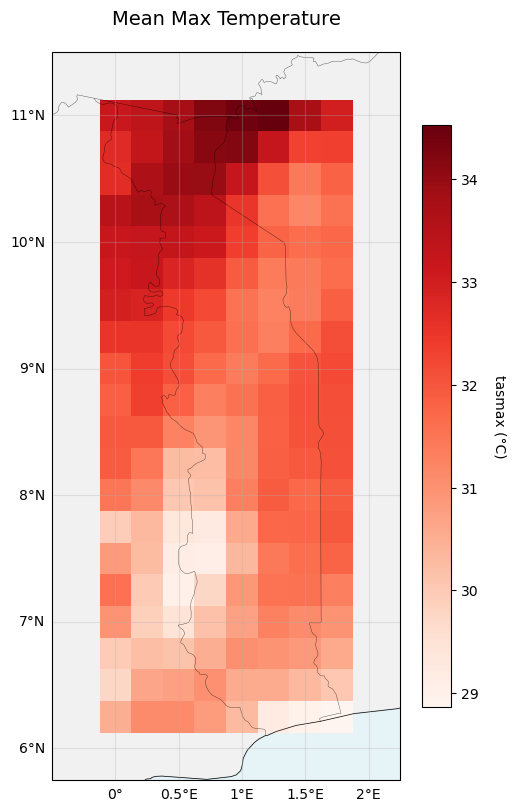

In [6]:
fig = cavapy.plot_spatial_map(
    CAVA_climate_data["tasmax"],
    time_period=(year-5, year+5),
    title="Mean Max Temperature",
    cmap="Reds",
)

## Exporting CAVA data

In [7]:
climate_folder = pre_proc_utilities.export_cava_data(ds, year, output_folder='./data_input/CAVA_data/', country_name = country_name)

Exporting pr...
Exporting tas...
Exporting tasmax...
Exporting tasmin...
Exporting hurs...
Exporting sfcWind...
Exporting rsds...

✅ Export complete. Files saved in: ./data_input/CAVA_data/Togo_20260930_143528


# Rasterized country AOI

Rasterized country saved to ./data_input/Togo_rasterized.tif


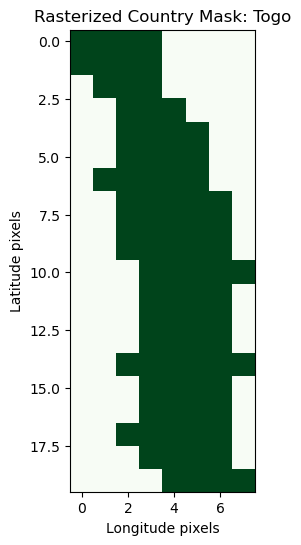

array([[1, 1, 1, 1, 0, 0, 0, 0],
       [1, 1, 1, 1, 0, 0, 0, 0],
       [0, 1, 1, 1, 0, 0, 0, 0],
       [0, 0, 1, 1, 1, 0, 0, 0],
       [0, 0, 1, 1, 1, 1, 0, 0],
       [0, 0, 1, 1, 1, 1, 0, 0],
       [0, 1, 1, 1, 1, 1, 0, 0],
       [0, 0, 1, 1, 1, 1, 1, 0],
       [0, 0, 1, 1, 1, 1, 1, 0],
       [0, 0, 1, 1, 1, 1, 1, 0],
       [0, 0, 0, 1, 1, 1, 1, 1],
       [0, 0, 0, 1, 1, 1, 1, 0],
       [0, 0, 0, 1, 1, 1, 1, 0],
       [0, 0, 0, 1, 1, 1, 1, 0],
       [0, 0, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 1, 1, 1, 1, 0],
       [0, 0, 0, 1, 1, 1, 1, 0],
       [0, 0, 1, 1, 1, 1, 1, 0],
       [0, 0, 0, 1, 1, 1, 1, 0],
       [0, 0, 0, 0, 1, 1, 1, 1]], dtype=uint8)

In [8]:
pre_proc_utilities.rasterize_country_from_geodataframe(ds, AOI, country_name, output_dir='./data_input/')

# DEM

## Defining the DEM for the AOI at the original resolution

Clipped raster saved to ./data_input/Togo_elevation_clipped.tif


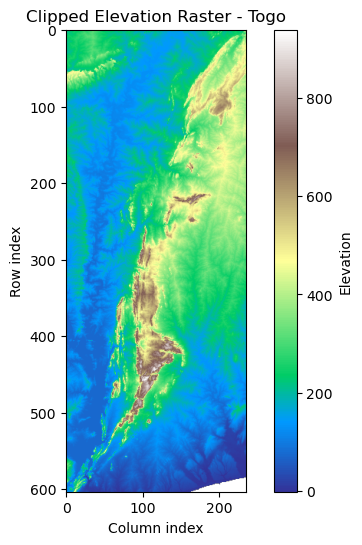

In [9]:
DEM_raster_path = r'./data_input/DEM/altmed30s.tif'
_ = pre_proc_utilities.clip_raster_with_geometry(DEM_raster_path, AOI, country_name, buffer, output_dir='./data_input/')

## Defining the DEM for the AOI at the scaled resolution

Unique values: [27. 28. 31. 49. 62. 69. 70. 71. 80. 81.]


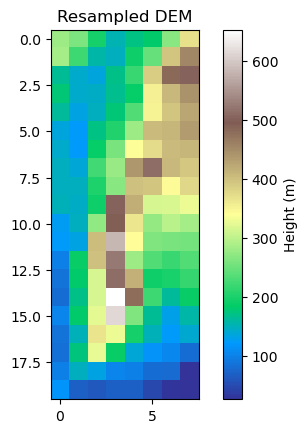

In [10]:
AOI_raster_path = f'./data_input/{country_name}_rasterized.tif'
ELV_raster_path = f'./data_input/{country_name}_elevation_resampled_clipped.tif'

elv = pre_proc_utilities.process_raster(INPUT_raster_path = './data_input/DEM/altmed30s.tif', 
                  ref_raster_path = AOI_raster_path,
                  output_clipped_path = ELV_raster_path,
                  ref_geom = AOI.geometry, buffer = buffer, plot=True, title = 'Resampled DEM', colorbar_label = 'Height (m)', cmap='terrain')


# LULC layer for the AOI at the scaled resolution

Unique values: [3. 4. 5. 6.]


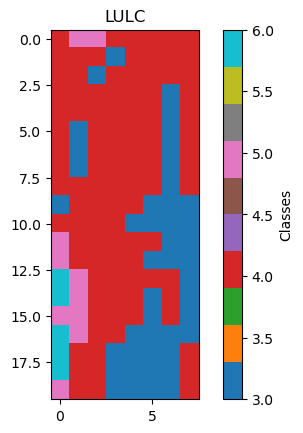

In [11]:
LULC_clipped_path = f'./data_input/{country_name}_lulc_resampled_clipped.tif'

lulc = pre_proc_utilities.process_raster(INPUT_raster_path = './data_input/LULC/soil_regime_CRUTS32_Hist_8110.tif', 
                  ref_raster_path = f'./data_input/{country_name}_rasterized.tif',
                  output_clipped_path = LULC_clipped_path,
                  ref_geom = AOI.geometry, buffer = buffer, plot=True, title = 'LULC', colorbar_label = 'Classes', cmap='tab10')

# Setting up data for Module 1

In [12]:
clim_reg = pre_proc_utilities.initialize_clim(year, country_name, daily=True, climate_folder = climate_folder)

C:\Users\dario\anaconda3\envs\PyAEZ-CAVApy\Lib\site-packages\numba\core\decorators.py:248: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
C:\Users\dario\anaconda3\envs\PyAEZ-CAVApy\Lib\site-packages\numba\core\decorators.py:248: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


# Setting up data for Module 2

In [13]:
aez = pre_proc_utilities.initialize_aez(year, country_name, management, daily=True, climate_folder = climate_folder)

These are the parameters selected for maize:



,Crop_name,SDG,input_level,HI,LAI,legume,adaptability,cycle_len,min_cycle_len,max_cycle_len,...,aLAI,bLAI,aHI,bHI,LnS,LsO,LO,HO,HsO,HnS
0,maize,6.0,high,0.45,4.0,0.0,8,135.0,108.0,148.5,...,NaN,NaN,NaN,NaN,2422.5,2550.0,2750.0,4725.0,5400.0,5670.0


# Setting up data for Module 3

In [14]:
clim_con = pre_proc_utilities.initialize_climatic_constraints(year, country_name, management, aez, climate_folder = climate_folder)


Agro-climatic constraints for rain-fed conditions when mean annual temperature > 20 degree
Please select the crop of interest:

--- Multiple matching rows found ---
These are the contraints you have selected:


,type,"0,29","30,59","60,89","90,119","120,149","150,179","180,209","210,239","240,269","270,299","300,329","330,364",365-,365+
455,b,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,25.0,25.0,25.0,25.0,50.0
456,c,50.0,50.0,50.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,25.0,50.0
457,d,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,30.0,30.0,30.0,30.0,30.0,30.0



Agro-climatic constraints for rain-fed conditions when mean annual temperature < 10 degree
Please select the crop of interest:

--- Multiple matching rows found ---
These are the contraints you have selected:


,type,"0,29","30,59","60,89","90,119","120,149","150,179","180,209","210,239","240,269","270,299","300,329","330,364",365-,365+
455,b,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,10.0,10.0,10.0,10.0,30.0
456,c,30.0,30.0,30.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,10.0,30.0
457,d,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,30.0,30.0,30.0,30.0,30.0,30.0



Agro-climatic constraints of early and late frost
Please select the crop of interest:

--- Multiple matching rows found ---
These are the contraints you have selected:


...

,type,"0,29","30,59","60,89","90,119","120,149","150,179","180,209","210,239","240,269","270,299","300,329","330,364",365-,365+
455,b,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,25.0,25.0,25.0,25.0,50.0
456,c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,25.0,50.0
457,d,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,30.0,30.0,30.0,30.0,30.0,30.0



Agro-climatic constraints for irrigated conditions when mean annual temperature < 10 degree
Please select the crop of interest:

--- Multiple matching rows found ---
These are the contraints you have selected:


,type,"0,29","30,59","60,89","90,119","120,149","150,179","180,209","210,239","240,269","270,299","300,329","330,364",365-,365+
455,b,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,10.0,10.0,10.0,10.0,30.0
456,c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,10.0,30.0
457,d,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,30.0,30.0,30.0,30.0,30.0,30.0



Agro-climatic constraints of early and late frost
Please select the crop of interest:

--- Multiple matching rows found ---
These are the contraints you have selected:


,type,"0,29","30,59","60,89","90,119","120,149","150,179","180,209","210,239","240,269","270,299","300,329","330,364","365,366"
39,e,0,0,0,0,0,0,0,0,0,0,0,0,0


<hr>

# END OF MODULE 0: INPUT DATA PREPARATION

<hr>